In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from optbinning import ContinuousOptimalBinning

## Hàm hỗ trợ

In [ ]:
def create_woe_df(x, y, splits):
    """
    Create WOE / IV table from manually specified or optimal splits.

    Parameters
    ----------
    x : pd.Series
        Feature values.
    y : pd.Series
        Binary target: 0 = non-event, 1 = event.
    splits : array-like
        Bin split points.

    Returns
    -------
    pd.DataFrame
        Bin, prob_n_obs, WOE, IV_detail, IV_total
    """

    # Make sure x/y have the same index
    data = pd.DataFrame({'x': x, 'target': y})
    bin_edges = [-np.inf] + list(splits) + [np.inf]

    data['bin'] = pd.cut(data['x'], bins=bin_edges, right=True, include_lowest=True)

    grouped = (data.groupby('bin', observed=False)['target']
        .agg(n_events=lambda s: (s == 1).sum(), n_non_events=lambda s: (s == 0).sum())
        .reset_index()
    )

    missing_mask = data['x'].isna()

    if missing_mask.any():
        missing_row = pd.DataFrame({
            'bin': ['Missing'],
            'n_events': [
                (missing_mask & (data['target'] == 1)).sum()
            ],
            'n_non_events': [
                (missing_mask & (data['target'] == 0)).sum()
            ]
        })

        grouped = pd.concat(
            [grouped, missing_row],
            ignore_index=True
        )

    total_obs = len(data)

    # Total events / non-events
    total_events = (data['target'] == 1).sum()
    total_non_events = (data['target'] == 0).sum()

    grouped['prob_n_obs'] = ((grouped['n_events'] + grouped['n_non_events'])/ total_obs)
    grouped['pct_event'] = (grouped['n_events'] / total_events if total_events > 0 else 0)
    grouped['pct_non_event'] = (grouped['n_non_events'] / total_non_events if total_non_events > 0 else 0)

    eps = 1e-6
    pct_event_adj = np.where(grouped['pct_event'] == 0, eps, grouped['pct_event'])
    pct_non_event_adj = np.where(grouped['pct_non_event'] == 0, eps, grouped['pct_non_event'])

    grouped['WOE'] = np.log(pct_event_adj / pct_non_event_adj)
    grouped['IV_detail'] = (pct_event_adj - pct_non_event_adj) * grouped['WOE']
    grouped['IV_total'] = grouped['IV_detail'].sum()
    grouped['Bin'] = grouped['bin'].astype(str)

    result = grouped[
        ['Bin', 'prob_n_obs', 'WOE', 'IV_detail', 'IV_total']
    ].copy()
    return result

In [ ]:
def get_bin_stats(x, y, splits):
    """
    Return observation count and proportion for each bin.
    Missing values are excluded because x used for optimization
    has already removed missing values.
    """
    bin_edges = [-np.inf] + list(splits) + [np.inf]

    bins = pd.cut(x, bins=bin_edges, right=True, include_lowest=True)

    stats = (pd.DataFrame({'bin': bins, 'target': y})
        .groupby('bin', observed=False)
        .size()
        .reset_index(name='n_obs')
    )
    stats['prob_n_obs'] = stats['n_obs'] / len(x)
    return stats

In [ ]:
def validate_splits(x, splits, min_n_bins, max_n_bins, min_bin_size, max_bin_size):
    """
    Validate manually edited split points.
    """

    splits = np.array(splits, dtype=float)

    # Check finite
    if not np.all(np.isfinite(splits)):
        return {'valid': False, 'message': 'Edited splits phải là các số finite.'}
    # Sort
    splits = np.sort(splits)
    # Check duplicate
    if len(np.unique(splits)) != len(splits):
        return {'valid': False, 'message': 'Edited splits chứa duplicate split point.'}

    n_bins = len(splits) + 1

    if n_bins < min_n_bins:
        return {
            'valid': False,
            'message': (
                f'Số bin = {n_bins}, nhỏ hơn min_n_bins = '
                f'{min_n_bins}.'
            )
        }

    if n_bins > max_n_bins:
        return {
            'valid': False,
            'message': (
                f'Số bin = {n_bins}, lớn hơn max_n_bins = '
                f'{max_n_bins}.'
            )
        }

    bin_stats = get_bin_stats(x=x, y=pd.Series(index=x.index, data=0), splits=splits)
    min_violation = bin_stats[bin_stats['prob_n_obs'] < min_bin_size].copy()

    max_violation = bin_stats[bin_stats['prob_n_obs'] > max_bin_size].copy()

    valid = (len(min_violation) == 0 and len(max_violation) == 0)

    return {
        'valid': valid,
        'n_bins': n_bins,
        'splits': splits,
        'bin_stats': bin_stats,
        'min_violation': min_violation,
        'max_violation': max_violation,
        'message': (
            'Edited splits hợp lệ.' if valid else 'Edited splits vi phạm bin-size constraint.'
        )
    }


In [ ]:
def plot_three_options(results, feature, x, y):
    """
    Compare 3 optimal binning strategies.

    Each subplot:
        - Left Y-axis  : WOE
        - Right Y-axis : Bin Count
        - X-axis       : Bin
    """

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    for ax_woe, (option_name, result) in zip(axes, results.items()):
        splits = result['splits']
        woe_df = create_woe_df(x, y, splits)
        woe_plot = woe_df[woe_df['Bin'] != 'Missing'].copy()

        bin_stats = get_bin_stats(x=x, y=y, splits=splits)

        n_bins = len(bin_stats)
        x_pos = np.arange(n_bins)

        ax_woe.plot(x_pos, woe_plot['WOE'].values, marker='o', linewidth=2, label='WOE')
        ax_woe.axhline(0, linestyle='--', linewidth=1)

        ax_woe.set_ylabel('WOE')
        ax_woe.set_xlabel('Bin')

        ax_woe.set_xticks(x_pos)
        ax_woe.set_xticklabels(bin_stats['bin'].astype(str), rotation=45, ha='right')
        ax_woe.grid(axis='y', alpha=0.3)

        ax_count = ax_woe.twinx()
        ax_count.bar(x_pos, bin_stats['n_obs'].values, alpha=0.25, width=0.6, label='Bin Count')
        ax_count.set_ylabel('Bin Count')

        ax_woe.set_title(option_name, fontsize=12)

        handles_woe, labels_woe = ax_woe.get_legend_handles_labels()
        handles_count, labels_count = ax_count.get_legend_handles_labels()

        ax_woe.legend(handles_woe + handles_count, labels_woe + labels_count, loc='best', fontsize=8)

    fig.suptitle(f'{feature} - WOE Trend & Bin Count Comparison', fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

## Đọc file csv

In [89]:
df = pd.read_csv('train_sdf_selected1.csv')

X_train = df.drop(columns=['LABEL'])
y = pd.Series(df['LABEL'].values, index=X_train.index)

## Chọn biến cần tính

In [90]:
feature = "A"

Chọn max_bin (không cần chỉnh, có thể giảm nếu cần)

In [91]:
max_bin = 10

### Tính lại min, max bin size
Vì drop missing và ZERO nên tỉ lệ ràng buộc 5% < x < 50% sẽ thay đổi

In [92]:
x = X_train[feature].copy()
mask_nonmissing = (
    x.notna()
    & (x != 0)
)

x = x.loc[mask_nonmissing]
y_clean = y.loc[mask_nonmissing]

n_old = len(X_train)
n_missing = X_train[feature].isna().sum()
n_zero = (X_train[feature] == 0).sum()
n_new = len(x)

min_bin_size = 0.05 * n_old / n_new
max_bin_size = min(0.50 * n_old / n_new, 1)

In [93]:
print('Original observations:', n_old)
print('Missing:', n_missing)
print('Zero:', n_zero)
print('Clean observations:', n_new)
print('Min bin size:', min_bin_size)
print('Max bin size:',max_bin_size)


Original observations: 64343
Missing: 43443
Zero: 0
Clean observations: 20900
Min bin size: 0.1539306220095694
Max bin size: 1


## 3 tùy chọn tính WOE

In [94]:
options = {
    '1. Free optimization': 'auto',
    '2. Monotonic': 'auto_asc_desc',
    '3. U-shape / heuristic': 'auto_heuristic'
}


In [95]:
results = {}

for option_name, trend in options.items():
    optb = ContinuousOptimalBinning(
        name=feature,
        dtype="numerical",
        min_n_bins=4,
        max_n_bins=max_bin,
        min_bin_size=min_bin_size,
        max_bin_size=max_bin_size,
        monotonic_trend=trend
    )
    optb.fit(x, y_clean)
    results[option_name] = {
        'model': optb,
        'splits': optb.splits,
        'binning_table': optb.binning_table
    }



### Trạng thái giải xu hướng WOE 
OPTIMAL - Giải thành công \
INFEASIBLE - Không giải được

In [110]:
print('OPTIMAL SPLITS')

for option_name, result in results.items():
    print(f'\n{option_name}')
    print('Status:', result['model'].status)
    print('Optimal splits:', list(map(float, result['splits'])))



OPTIMAL SPLITS

1. Free optimization
Status: OPTIMAL
Optimal splits: [3.5, 10.5, 57.5]

2. Monotonic
Status: OPTIMAL
Optimal splits: [3.5, 13.5, 57.5]

3. U-shape / heuristic
Status: OPTIMAL
Optimal splits: [3.5, 10.5, 57.5]


### Biểu đồ WOE ở 3 configs

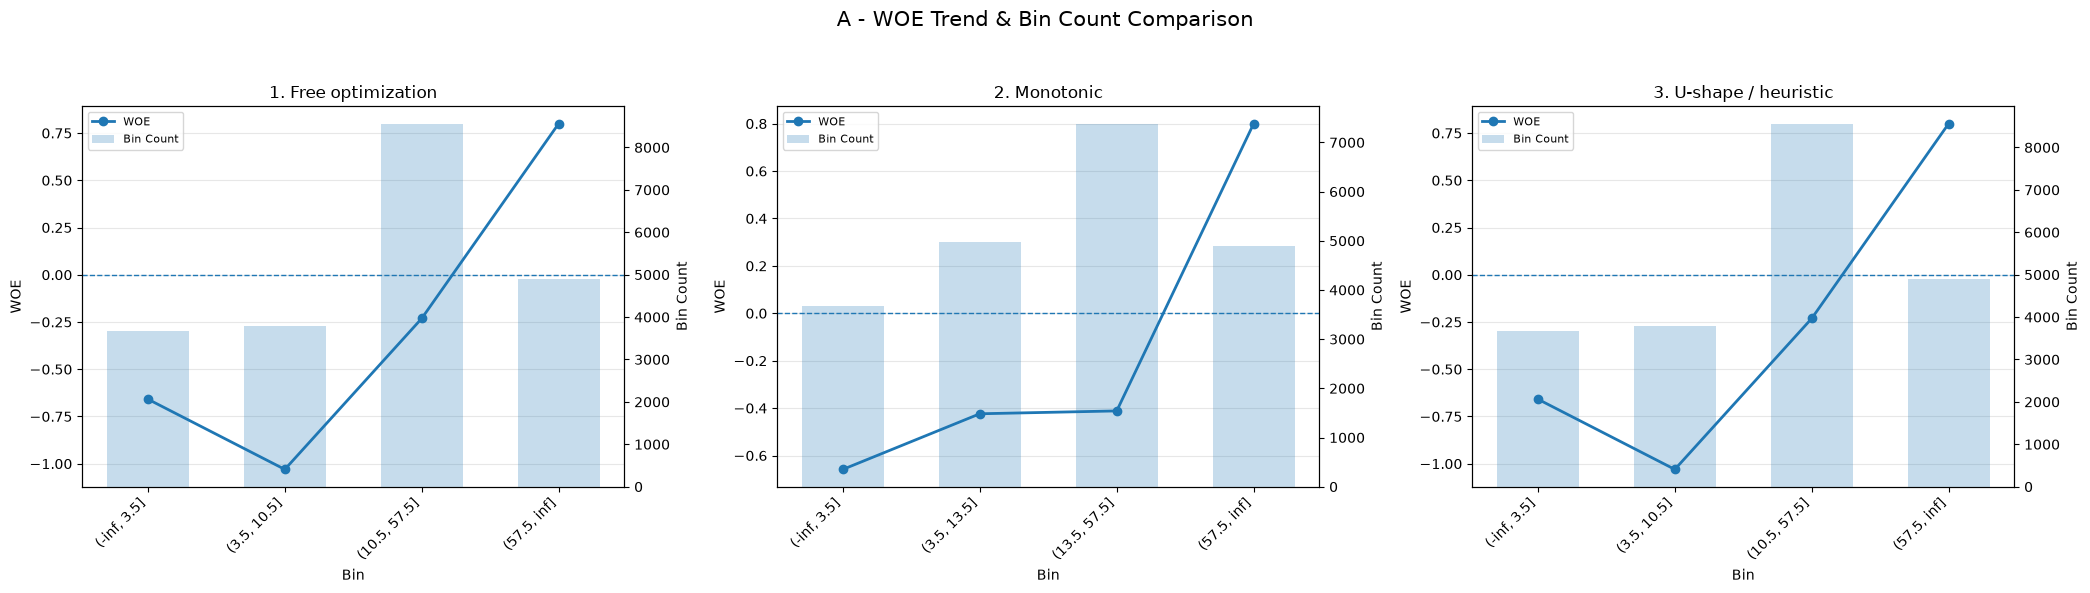

In [97]:
plot_three_options(results, feature,x, y_clean)


### Bảng thông tin WOE và IV

In [98]:
print('WOE TABLES')
woe_tables = {}
for option_name, result in results.items():
    print(option_name)
    splits = result['splits']
    woe_df = create_woe_df(x, y_clean, splits)
    woe_tables[option_name] = woe_df
    display(
        woe_df.style.format({'prob_n_obs': '{:.2%}', 'WOE': '{:.4f}',
            'IV_detail': '{:.4f}', 'IV_total': '{:.4f}'})
    )

WOE TABLES
1. Free optimization


,Bin,prob_n_obs,WOE,IV_detail,IV_total
0,"(-inf, 3.5]",17.53%,-0.6585,0.0558,0.4247
1,"(3.5, 10.5]",18.15%,-1.0301,0.1205,0.4247
2,"(10.5, 57.5]",40.88%,-0.2311,0.0195,0.4247
3,"(57.5, inf]",23.44%,0.8001,0.2289,0.4247


2. Monotonic


,Bin,prob_n_obs,WOE,IV_detail,IV_total
0,"(-inf, 3.5]",17.53%,-0.6585,0.0558,0.3686
1,"(3.5, 13.5]",23.78%,-0.4238,0.0349,0.3686
2,"(13.5, 57.5]",35.24%,-0.4118,0.0491,0.3686
3,"(57.5, inf]",23.44%,0.8001,0.2289,0.3686


3. U-shape / heuristic


,Bin,prob_n_obs,WOE,IV_detail,IV_total
0,"(-inf, 3.5]",17.53%,-0.6585,0.0558,0.4247
1,"(3.5, 10.5]",18.15%,-1.0301,0.1205,0.4247
2,"(10.5, 57.5]",40.88%,-0.2311,0.0195,0.4247
3,"(57.5, inf]",23.44%,0.8001,0.2289,0.4247


## Tùy chỉnh khoảng bin 

In [99]:
results['1. Free optimization']['splits']

array([ 3.5, 10.5, 57.5])

In [107]:
edited_splits = [3, 10, 57]

Nếu không thỏa điều kiện, sẽ raise lỗi

In [108]:
validation = validate_splits(x=x, splits=edited_splits, min_n_bins=4, max_n_bins=max_bin, min_bin_size=min_bin_size, max_bin_size=max_bin_size)

print(f"Edited splits: {edited_splits}")
print(f"Number of bins: {validation.get('n_bins')}")

if not validation['valid']:
    print("Result: Edited splits không hợp lệ.")

    if validation.get('n_bins', 0) < 4:
        print(f"- Số bin = {validation['n_bins']}, nhỏ hơn min_n_bins = 4.")
    elif validation.get('n_bins', 0) > max_bin:
        print(f"- Số bin = {validation['n_bins']}, lớn hơn max_n_bins = {max_bin}.")

    min_violation = validation.get('min_violation', pd.DataFrame())
    if not min_violation.empty:
        print(f"- Các bin có prob_n_obs < min_bin_size ({min_bin_size:.2%}):")
        display(min_violation.style.format({'prob_n_obs': '{:.2%}'}))

    max_violation = validation.get('max_violation', pd.DataFrame())
    if not max_violation.empty:
        print(f"- Các bin có prob_n_obs > max_bin_size ({max_bin_size:.2%}):")
        display(max_violation.style.format({'prob_n_obs': '{:.2%}'}))

    raise ValueError("Hãy chỉnh lại edited_splits.")

print("Result: Edited splits hợp lệ.")
splits = validation['splits']
print(f"Valid edited splits: {list(map(float, splits))}")
display(validation['bin_stats'].style.format({'prob_n_obs': '{:.2%}'}))

Edited splits: [3, 10, 57]
Number of bins: 4
Result: Edited splits hợp lệ.
Valid edited splits: [3.0, 10.0, 57.0]


,bin,n_obs,prob_n_obs
0,"(-inf, 3.0]",3664,17.53%
1,"(3.0, 10.0]",3793,18.15%
2,"(10.0, 57.0]",8543,40.88%
3,"(57.0, inf]",4900,23.44%


,Bin,prob_n_obs,WOE,IV_detail,IV_total
0,"(-inf, 3.0]",17.53%,-0.6585,0.0558,0.4247
1,"(3.0, 10.0]",18.15%,-1.0301,0.1205,0.4247
2,"(10.0, 57.0]",40.88%,-0.2311,0.0195,0.4247
3,"(57.0, inf]",23.44%,0.8001,0.2289,0.4247


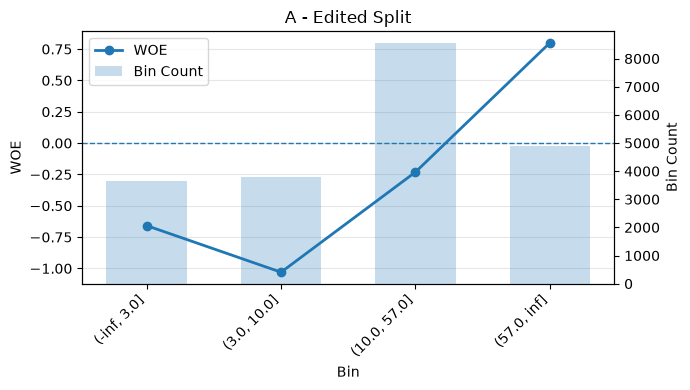

In [111]:
edited_woe_df = create_woe_df(x, y_clean, splits)

display(edited_woe_df.style.format({'prob_n_obs': '{:.2%}','WOE': '{:.4f}','IV_detail': '{:.4f}','IV_total': '{:.4f}'}))

bin_stats = get_bin_stats(x=x, y=y_clean, splits=splits)

woe_plot = edited_woe_df[edited_woe_df['Bin'] != 'Missing'].copy()

x_pos = np.arange(len(woe_plot))
fig, ax_woe = plt.subplots(figsize=(7, 4))

ax_woe.plot(x_pos, woe_plot['WOE'], marker='o', linewidth=2, label='WOE')
ax_woe.axhline(0, linestyle='--', linewidth=1)

ax_woe.set_xlabel('Bin')
ax_woe.set_ylabel('WOE')
ax_woe.set_xticks(x_pos)
ax_woe.set_xticklabels(woe_plot['Bin'], rotation=45, ha='right')
ax_woe.grid(axis='y', alpha=0.3)

ax_count = ax_woe.twinx()
ax_count.bar(x_pos, bin_stats['n_obs'], alpha=0.25, width=0.6, label='Bin Count')

ax_count.set_ylabel('Bin Count')
ax_woe.set_title(f'{feature} - Edited Split')

handles_woe, labels_woe = ax_woe.get_legend_handles_labels()
handles_count, labels_count = ax_count.get_legend_handles_labels()

ax_woe.legend(handles_woe + handles_count, labels_woe + labels_count, loc='best')

plt.tight_layout()
plt.show()